# 1.Ultralytics YOLO11
- YOLO(You Only Look Once): 이미지나 비디오에서 객체를 실시간으로 탐지하는 딥러닝 모델 시리즈
- YOLOv4 까지는 C언어 기반의 Darknet 아키텍처가 사용되었지만, YOLOv5 부터는 Pytorch로 개발이 이루어짐
- 주요 특징
    - 향상된 성능: YOLOv8m 대비 22% 적은 매개변수로 더 높은 mAP(mean Average Precision)를 달성
    - 다양한 작업 지원: 객체 탐지, 인스턴스 분할, 이미지 분류, 자세 추정 등 다양한 컴퓨터 비전 작업을 지원
    - 효율성 및 속도 최적화: 정교한 아키텍처 설계와 최적화된 학습 파이프라인을 통해 처리 속도를 높이면서도 정확도를 유지
- pre-trained model, 학습데이터 정보인 yaml 파일만 바꾸어 주면 동일한 파이썬 API를 이용해서 다양한 작업을 할 수 있음
- https://docs.ultralytics.com/ko/models/yolo11/
- https://github.com/ultralytics/ultralytics




# 2.커스텀 데이터 학습

- https://docs.ultralytics.com/ko/modes/train/#train-settings


## 2.1.커스텀 데이터 학습 절차

1. 데이터 수집 및 라벨링: 커스텀 데이터셋을 수집하고, 각 객체에 대한 라벨링을 수행한다.
2. 데이터셋 구성 파일 작성: 데이터셋의 경로, 클래스 정보 등을 포함한 YAML 파일을 작성한다.
3. 모델 구성 파일 준비: 모델의 아키텍처와 하이퍼파라미터를 정의한 YAML 파일을 준비한다.
4. 모델 학습: 준비된 데이터와 구성 파일을 사용하여 모델을 학습시킨다.
5. 모델 평가 및 추론: 학습된 모델을 평가하고, 새로운 이미지에 대해 객체 탐지를 수행한다.

## 2.2.커스텀 데이터 준비하기

- https://universe.roboflow.com/
- Object Detection을 위한 이미지와 정답 데이터가 함께 제공되는 RoboFlow사이트에서 커스텀 데이터 준비

In [1]:
%pip install roboflow

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="c3SG548ha7FLkydbCJFt")
project = rf.workspace("dohoons-workspace-eea1j").project("rock-paper-scissors-sxsw-r4c5k")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [3]:
!cat /content/rock-paper-scissors-1/data.yaml

cat: /rock-paper-scissors-1/data.yaml: No such file or directory


## 2.3.YAML 파일 만들기(중요)
- YOLOv11 학습과 검증에 필요한 train, valid 데이터의 디렉토리 경로와 Detection하고 싶은 클래스 개수 그리고 해당 클래스의 (문자열)이름이 저장되어 있는 YAML 파일을 반드시 만들어 줘야 함

In [4]:
%pip install PyYAML

In [5]:
import yaml

In [6]:
data = {'train': '/rock-paper-scissors-1/train/images/',
        'val':'/rock-paper-scissors-1/valid/images/',
        'test':'/rock-paper-scissors-1/test/images/',
        'name': ['Paper', 'Rock', 'Scissors'],
        'nc':3}

In [7]:
# 데이터 경로와 클래스 정보를 저장하고 있는 딕셔너리 객체 data를 YOLO11 학습에 필요한 rock-paper-scissors_data.yaml 저장
with open('rock-paper-scissors-1/rock-paper-scissors_data.yaml', 'w') as f:
    yaml.dump(data, f)

In [8]:
with open('rock-paper-scissors-1/rock-paper-scissors_data.yaml', 'r') as f:
    display(yaml.safe_load(f))

{'name': ['Paper', 'Rock', 'Scissors'],
 'nc': 3,
 'test': '/rock-paper-scissors-1/test/images/',
 'train': '/rock-paper-scissors-1/train/images/',
 'val': '/rock-paper-scissors-1/valid/images/'}

# 3.YOLO11로 학습 시키기

- Install YOLO11

In [9]:
%pip install ultralytics

## 3.1.사전학습 모델 로드(for Object Detection)

In [10]:
import torch
import ultralytics
from ultralytics import YOLO

In [11]:
# YOLO11 모델 다운로드 및 로드
model = YOLO('yolo11n.pt')

In [12]:
print(len(model.names))
print(model.names)

80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'mic

## 3.2.YOLO11 커스텀 데이터 학습하기

In [ ]:
model.train(data='rock-paper-scissors-1/data.yaml', epochs=30, patience=5, imgsz=640)

In [15]:
model = YOLO('/content/runs/detect/train/weights/best.pt')

print(len(model.names))
print(model.names)

3
{0: 'Paper', 1: 'Rock', 2: 'Scissors'}


## 3.3.파인튜닝된 YOLO11 이용해서 테스트 이미지 예측

<IPython.core.display.Javascript object>

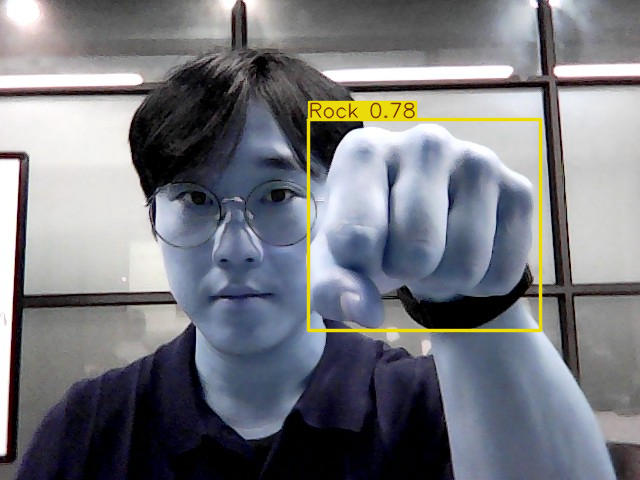

In [20]:
# Colab용 웹캠 한 장 캡처 -> Yolo 추론

import cv2, numpy as np, base64
from google.colab.output import eval_js
from IPython.display import Javascript, display
from google.colab.patches import cv2_imshow

# JS: 브라우저 권한으로 웹캠 열고 1장 캡처 후 dataURL 반환
js = r"""
async function captureImage(){
  const div = document.createElement('div');
  const video = document.createElement('video');
  const btn = document.createElement('button');
  btn.textContent = '📸 Capture';
  btn.style = 'margin-top:8px;padding:6px 12px;font-size:16px';

  div.appendChild(video);
  div.appendChild(document.createElement('br'));
  div.appendChild(btn);
  document.body.appendChild(div);

  const stream = await navigator.mediaDevices.getUserMedia({video:true});
  video.srcObject = stream;
  await video.play();

  // Capture 버튼을 기다림
  await new Promise(resolve => btn.onclick = resolve);

  // 캔버스로 복사
  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);

  // 정리
  stream.getTracks().forEach(t => t.stop());
  div.remove();

  return canvas.toDataURL('image/jpeg', 0.9);
}
"""
display(Javascript(js))

# 1회 캡처
data = eval_js("captureImage()")   # 'data:image/jpeg;base64,...'
header, b64data = data.split(',', 1)
img_bytes = base64.b64decode(b64data)
img_np = np.frombuffer(img_bytes, np.uint8)
frame = cv2.imdecode(img_np, cv2.IMREAD_COLOR)

# YOLO 추론
results = model.predict(frame, imgsz=640, conf=0.25, device=0 if cv2.cuda.getCudaEnabledDeviceCount() else 'cpu', verbose=False)
annotated = results[0].plot()  # 박스/라벨 그려진 프레임(BGR)

cv2_imshow(annotated[:, :, ::-1])  # Colab은 RGB가 잘 보임
